In [11]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import io
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import read_log

In [7]:
def get_thrs(price_df, ema_mean, ema_std):
    ema_var = ema_std ** 2
    
    window_size = 10000
    alpha = 2 / (window_size + 1)
    
    estimated_means = []
    estimated_stds = []
    
    # 3. EMA Updating Loop
    for price in price_df['mid_price']:
        # Calculate difference from the *old* mean
        diff = price - ema_mean
        
        # Update Variance FIRST (Mathematically requires the difference from the old mean)
        ema_var = (1 - alpha) * (ema_var + alpha * (diff ** 2))
        
        # Update Mean SECOND
        ema_mean = ema_mean + (alpha * diff)
        
        # Calculate instantaneous dynamic standard deviation
        current_std = math.sqrt(ema_var)
        
        estimated_means.append(ema_mean)
        estimated_stds.append(current_std)
    
    # 4. Save to DataFrame
    price_df['estimated_mean'] = estimated_means
    price_df['estimated_std'] = estimated_stds

    return price_df

# ROUND 1

In [2]:
path = '../backtests/round_1/submission.log'
with open(path, 'r') as f:
    data = json.load(f)

In [3]:
data.keys()

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])

In [4]:
activities = pd.read_csv(io.StringIO(data['activitiesLog']), sep=';')
trades = pd.DataFrame(data['tradeHistory'])

In [5]:
price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

In [6]:
print(f'Pepper First 1000 ts PnL: {price_pepper['profit_and_loss'].iloc[999]}')
print(f'Osmium First 1000 ts PnL: {price_osmium['profit_and_loss'].iloc[999]}')
print(f'Total First 1000 ts PnL: {price_pepper['profit_and_loss'].iloc[999] + price_osmium['profit_and_loss'].iloc[999]}')
print()
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Total Final PnL: {price_pepper['profit_and_loss'].iloc[-1] + price_osmium['profit_and_loss'].iloc[-1]}')

Pepper First 1000 ts PnL: 7365.0
Osmium First 1000 ts PnL: 2149.0
Total First 1000 ts PnL: 9514.0

Pepper Final PnL: 80405.0
Osmium Final PnL: 19568.0
Total Final PnL: 99973.0


In [7]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

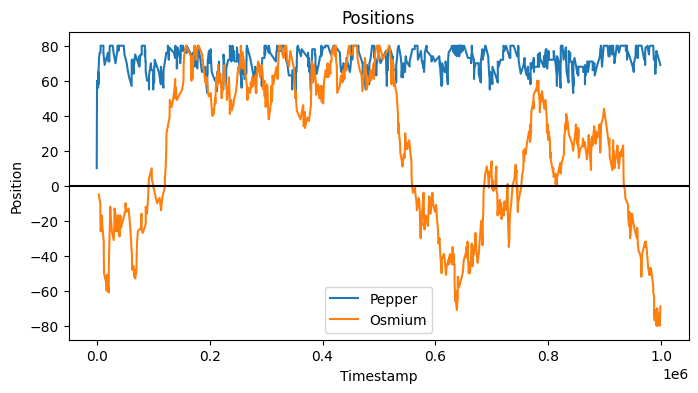

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'], label='Pepper')
plt.plot(trades_osmium['position'], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions')
plt.legend()
plt.show()

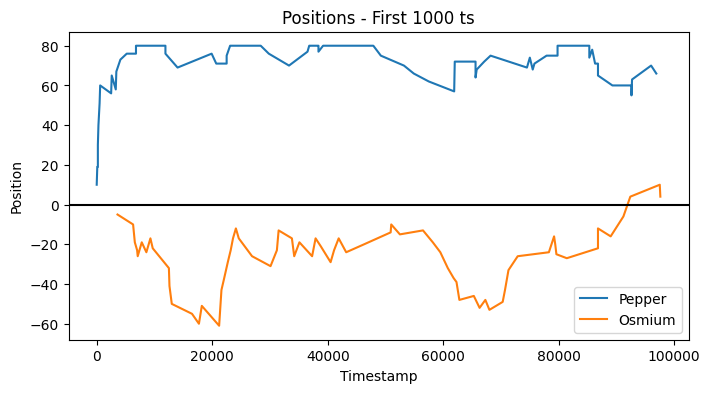

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'].loc[:99900], label='Pepper')
plt.plot(trades_osmium['position'].loc[:99900], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions - First 1000 ts')
plt.legend()
plt.show()

In [10]:
pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]

C:\Users\aeali\AppData\Local\Temp\ipykernel_23076\1080791694.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
C:\Users\aeali\AppData\Local\Temp\ipykernel_23076\1080791694.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]


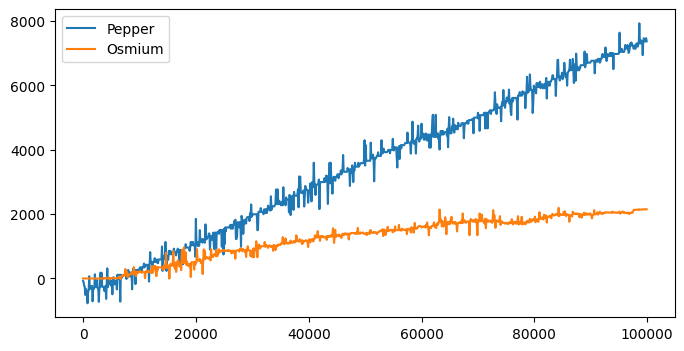

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(pepper_pnl, label='Pepper')
plt.plot(osmium_pnl, label='Osmium')
plt.legend()
plt.show()

# ROUND 2

In [12]:
path = '../backtests/round_2/submission.log'
with open(path, 'r') as f:
    data = json.load(f)

activities = pd.read_csv(io.StringIO(data['activitiesLog']), sep=';')
trades = pd.DataFrame(data['tradeHistory'])

price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

In [13]:
print(f'Pepper First 1000 ts PnL: {price_pepper['profit_and_loss'].iloc[999]}')
print(f'Osmium First 1000 ts PnL: {price_osmium['profit_and_loss'].iloc[999]}')
print(f'Total First 1000 ts PnL: {price_pepper['profit_and_loss'].iloc[999] + price_osmium['profit_and_loss'].iloc[999]}')
print()
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Total Final PnL: {price_pepper['profit_and_loss'].iloc[-1] + price_osmium['profit_and_loss'].iloc[-1]}')

Pepper First 1000 ts PnL: 7472.0
Osmium First 1000 ts PnL: 1793.0
Total First 1000 ts PnL: 9265.0

Pepper Final PnL: 80573.0
Osmium Final PnL: 20458.0
Total Final PnL: 101031.0


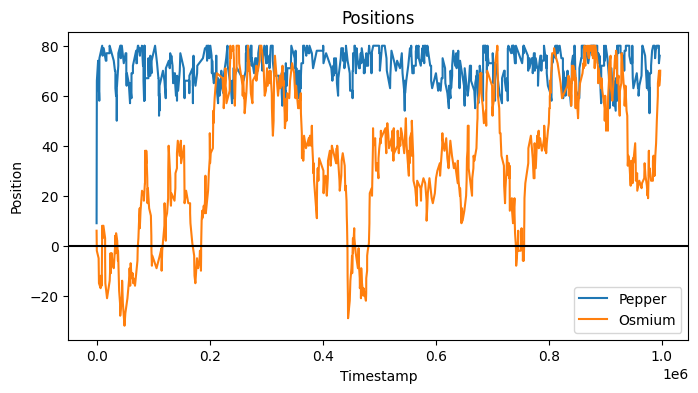

In [14]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'], label='Pepper')
plt.plot(trades_osmium['position'], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions')
plt.legend()
plt.show()

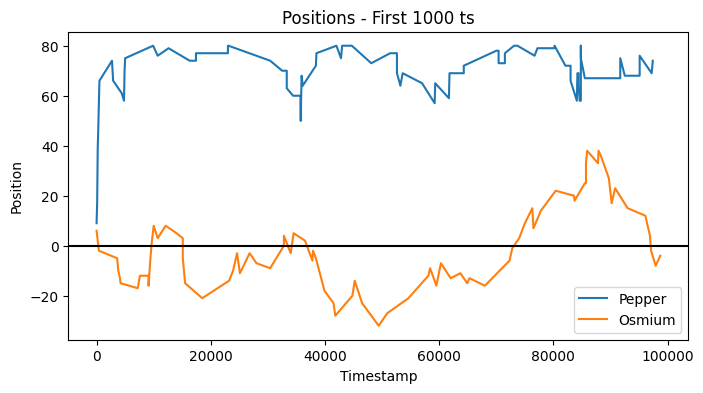

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(trades_pepper['position'].loc[:99900], label='Pepper')
plt.plot(trades_osmium['position'].loc[:99900], label='Osmium')
plt.axhline(0, c='k')
plt.xlabel('Timestamp')
plt.ylabel('Position')
plt.title('Positions - First 1000 ts')
plt.legend()
plt.show()

C:\Users\aeali\AppData\Local\Temp\ipykernel_23076\2500109934.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
C:\Users\aeali\AppData\Local\Temp\ipykernel_23076\2500109934.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]


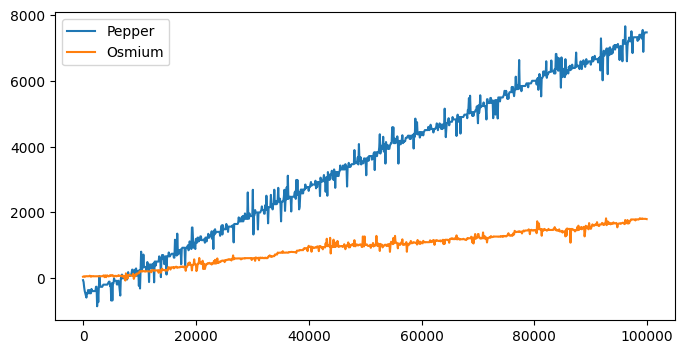

In [16]:
pepper_pnl = price_pepper[price_pepper['profit_and_loss'] >= -1000][price_pepper['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]
osmium_pnl = price_osmium[price_osmium['profit_and_loss'] >= -1000][price_osmium['profit_and_loss'] <= 70000]['profit_and_loss'].loc[:99900]

plt.figure(figsize=(8, 4))
plt.plot(pepper_pnl, label='Pepper')
plt.plot(osmium_pnl, label='Osmium')
plt.legend()
plt.show()

# ROUND 5

In [13]:
path = '../backtests/round_5/submission.log'
with open(path, 'r') as f:
    data = json.load(f)

activities = pd.read_csv(io.StringIO(data['activitiesLog']), sep=';')
trades = pd.DataFrame(data['tradeHistory'])

In [14]:
total_pnl = 0
products = [
    "GALAXY_SOUNDS_DARK_MATTER", 
    "GALAXY_SOUNDS_BLACK_HOLES", 
    "GALAXY_SOUNDS_PLANETARY_RINGS", 
    "GALAXY_SOUNDS_SOLAR_WINDS", 
    "GALAXY_SOUNDS_SOLAR_FLAMES", 
    # "SLEEP_POD_SUEDE", 
    # "SLEEP_POD_LAMB_WOOL", 
    # "SLEEP_POD_POLYESTER", 
    # "SLEEP_POD_NYLON", 
    # "SLEEP_POD_COTTON", 
    # "MICROCHIP_CIRCLE", 
    # "MICROCHIP_OVAL", 
    # "MICROCHIP_SQUARE", 
    # "MICROCHIP_RECTANGLE", 
    # "MICROCHIP_TRIANGLE", 
    # "PEBBLES_XS", 
    # "PEBBLES_S", 
    # "PEBBLES_M", 
    # "PEBBLES_L", 
    # "PEBBLES_XL", 
    # "ROBOT_VACUUMING", 
    # "ROBOT_MOPPING", 
    # "ROBOT_DISHES", 
    # "ROBOT_LAUNDRY", 
    # "ROBOT_IRONING", 
    "UV_VISOR_YELLOW", 
    "UV_VISOR_AMBER", 
    "UV_VISOR_ORANGE", 
    "UV_VISOR_RED", 
    "UV_VISOR_MAGENTA", 
    # "TRANSLATOR_SPACE_GRAY", 
    # "TRANSLATOR_ASTRO_BLACK", 
    # "TRANSLATOR_ECLIPSE_CHARCOAL", 
    # "TRANSLATOR_GRAPHITE_MIST", 
    # "TRANSLATOR_VOID_BLUE", 
    "PANEL_1X2", 
    "PANEL_2X2", 
    "PANEL_1X4", 
    "PANEL_2X4", 
    "PANEL_4X4", 
    # "OXYGEN_SHAKE_MORNING_BREATH", 
    # "OXYGEN_SHAKE_EVENING_BREATH", 
    # "OXYGEN_SHAKE_MINT", 
    # "OXYGEN_SHAKE_CHOCOLATE", 
    # "OXYGEN_SHAKE_GARLIC", 
    # "SNACKPACK_CHOCOLATE", 
    # "SNACKPACK_VANILLA", 
    # "SNACKPACK_PISTACHIO", 
    # "SNACKPACK_STRAWBERRY", 
    # "SNACKPACK_RASPBERRY", 
]

GALAXY_SOUNDS_DARK_MATTER PnL: 3322.5


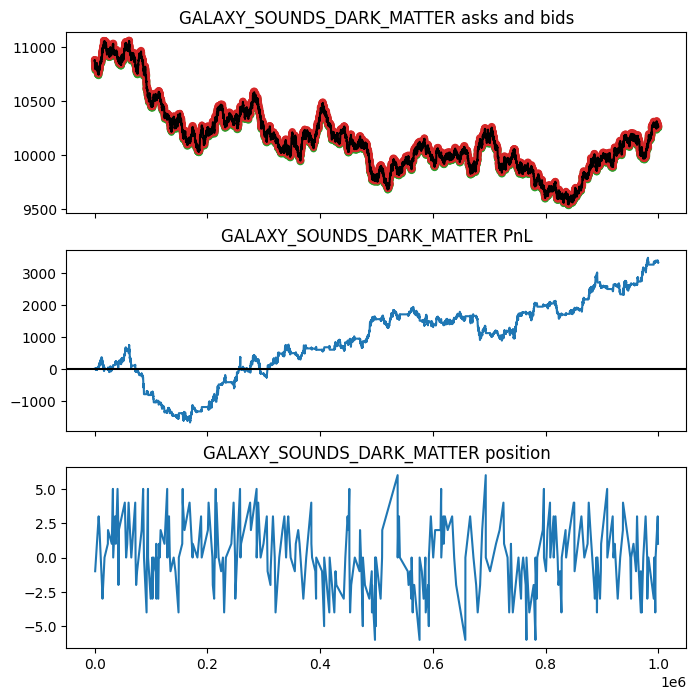

######################################################################################################################################################
GALAXY_SOUNDS_BLACK_HOLES PnL: 2966.0


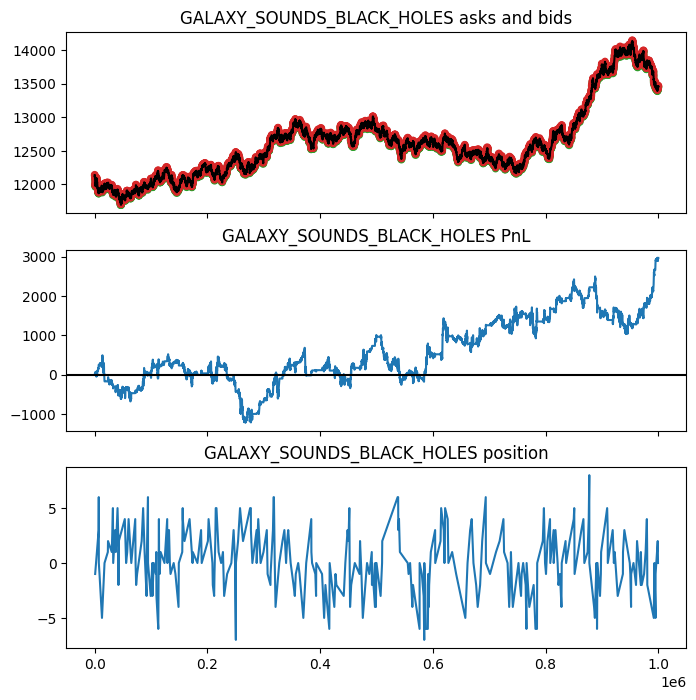

######################################################################################################################################################
GALAXY_SOUNDS_PLANETARY_RINGS PnL: 247.0


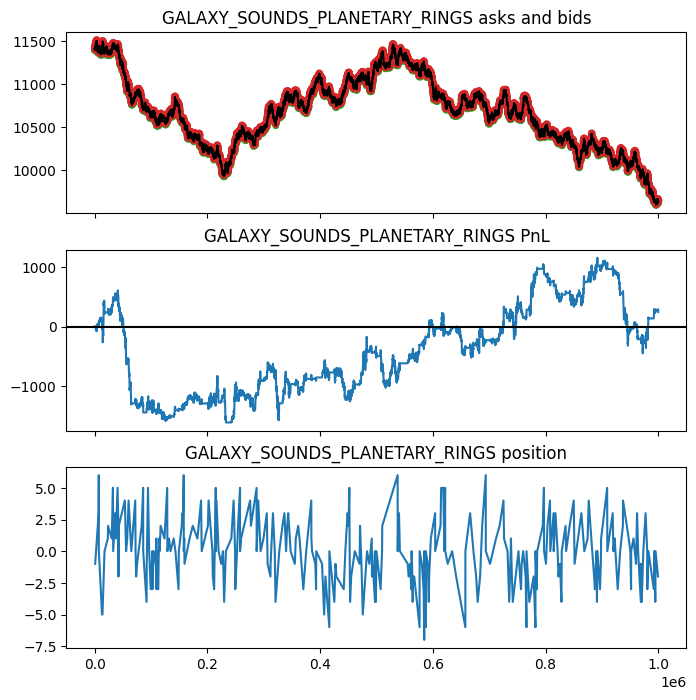

######################################################################################################################################################
GALAXY_SOUNDS_SOLAR_WINDS PnL: 3942.5


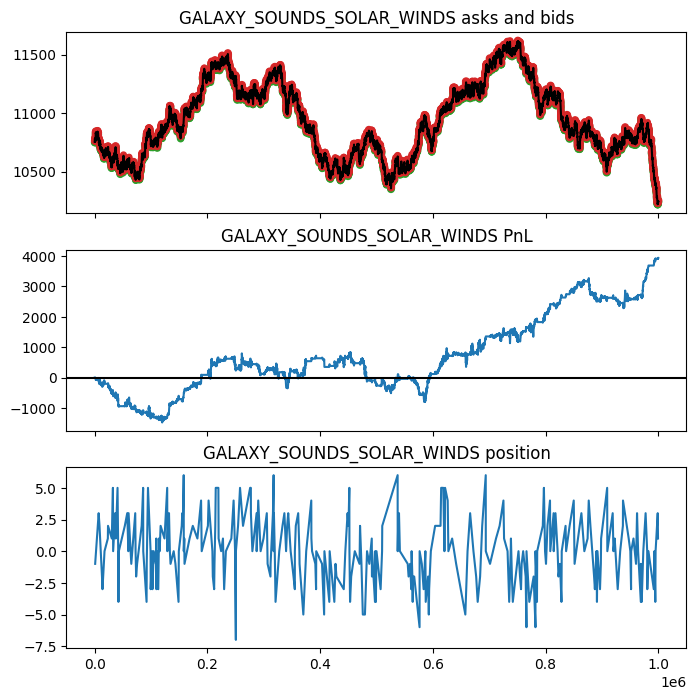

######################################################################################################################################################
GALAXY_SOUNDS_SOLAR_FLAMES PnL: 1030.0


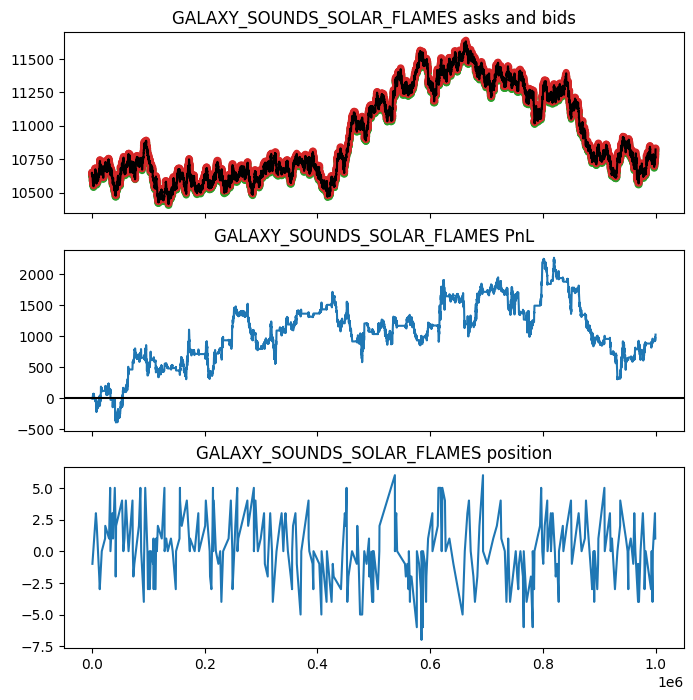

######################################################################################################################################################
UV_VISOR_YELLOW PnL: 4224.0


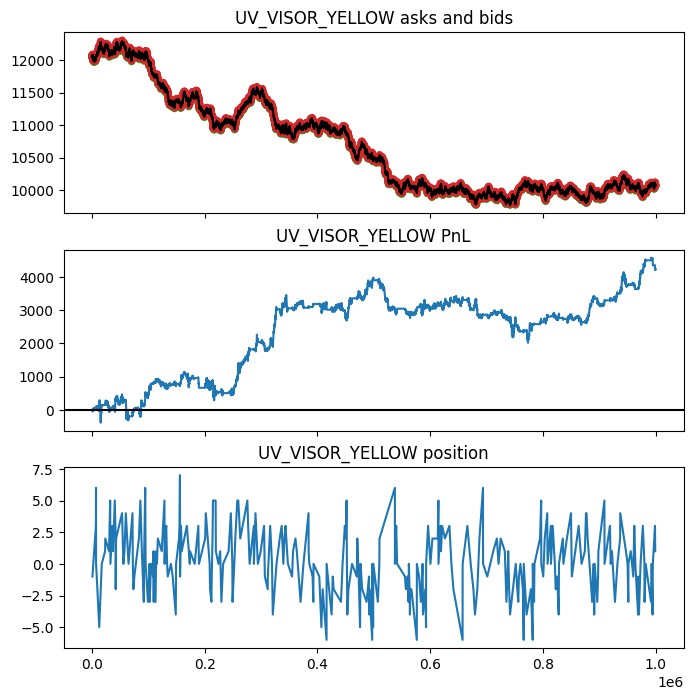

######################################################################################################################################################
UV_VISOR_AMBER PnL: 1484.0


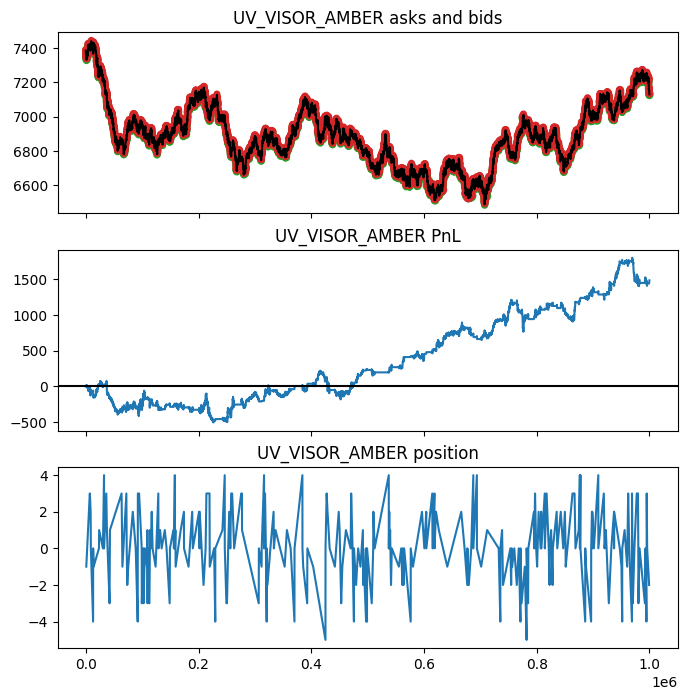

######################################################################################################################################################
UV_VISOR_ORANGE PnL: 1577.0


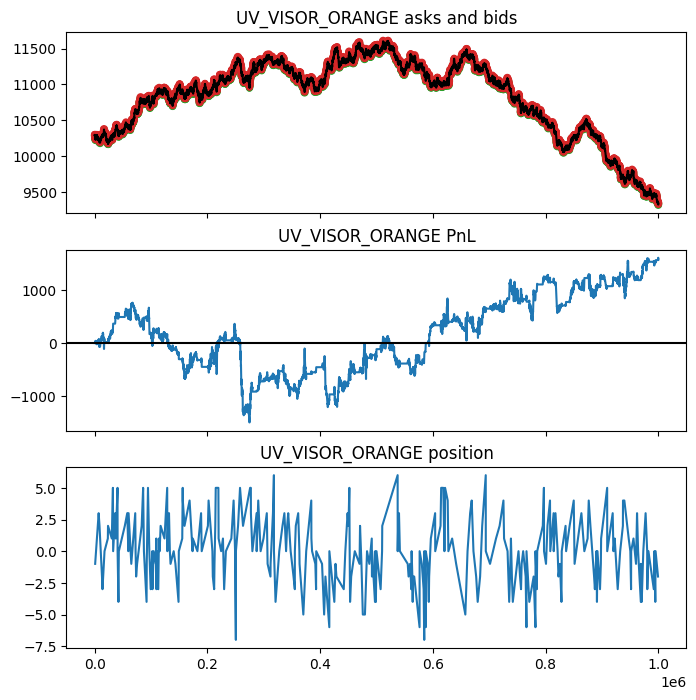

######################################################################################################################################################
UV_VISOR_RED PnL: -1956.5


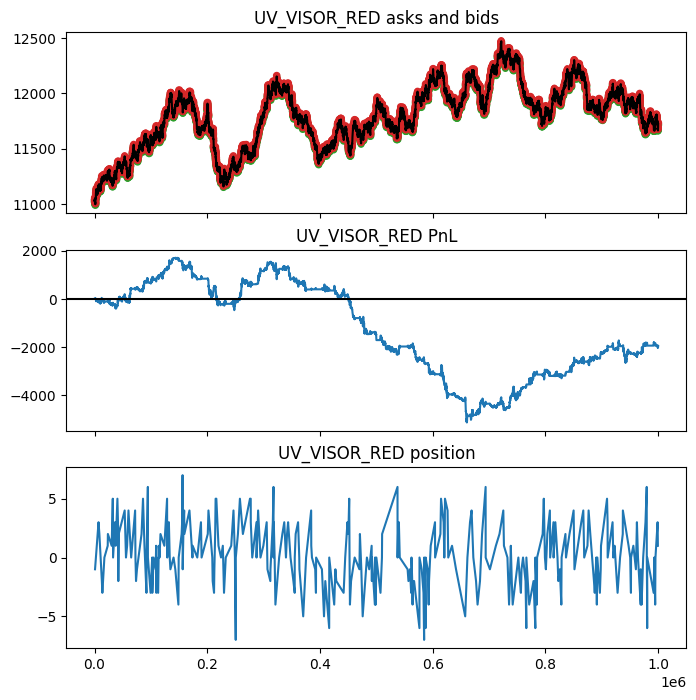

######################################################################################################################################################
UV_VISOR_MAGENTA PnL: -1251.5


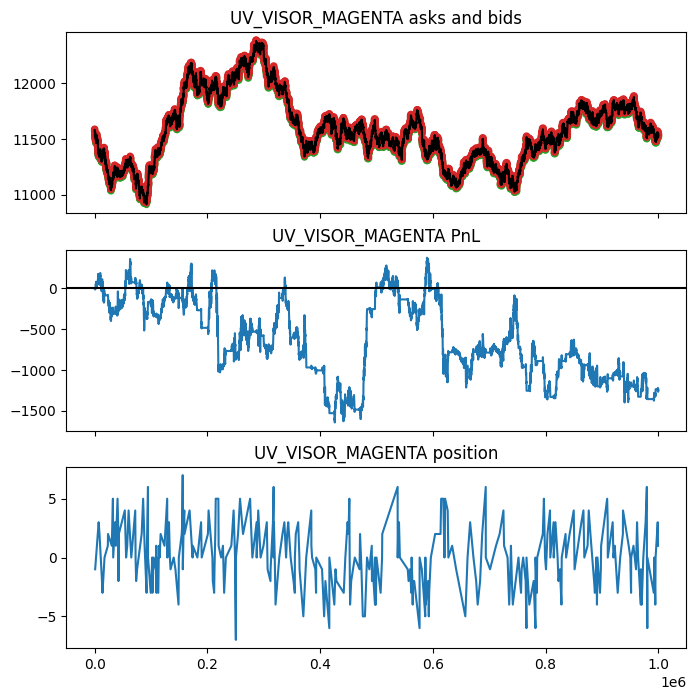

######################################################################################################################################################
PANEL_1X2 PnL: -964.0


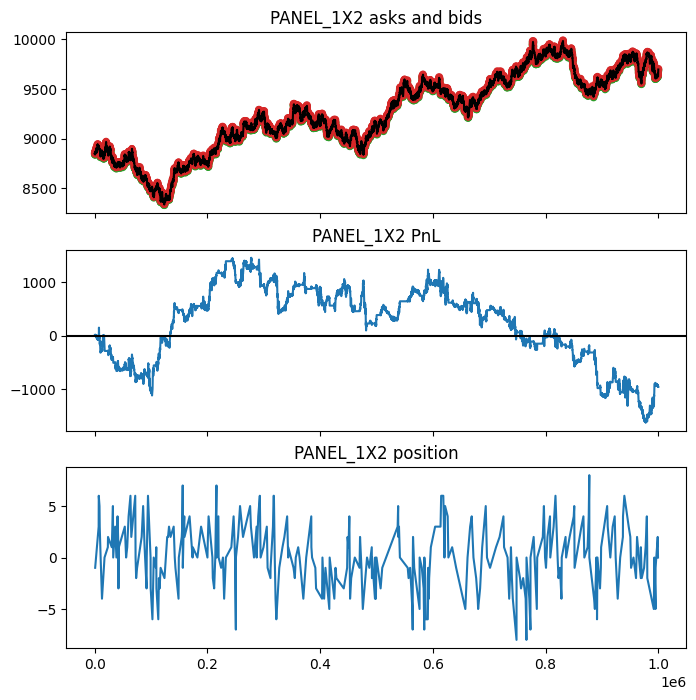

######################################################################################################################################################
PANEL_2X2 PnL: -1424.0


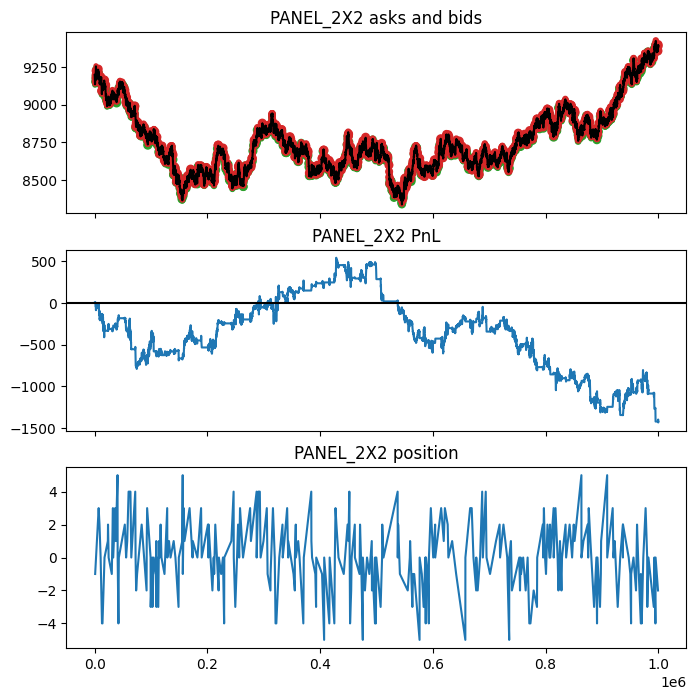

######################################################################################################################################################
PANEL_1X4 PnL: 358.5


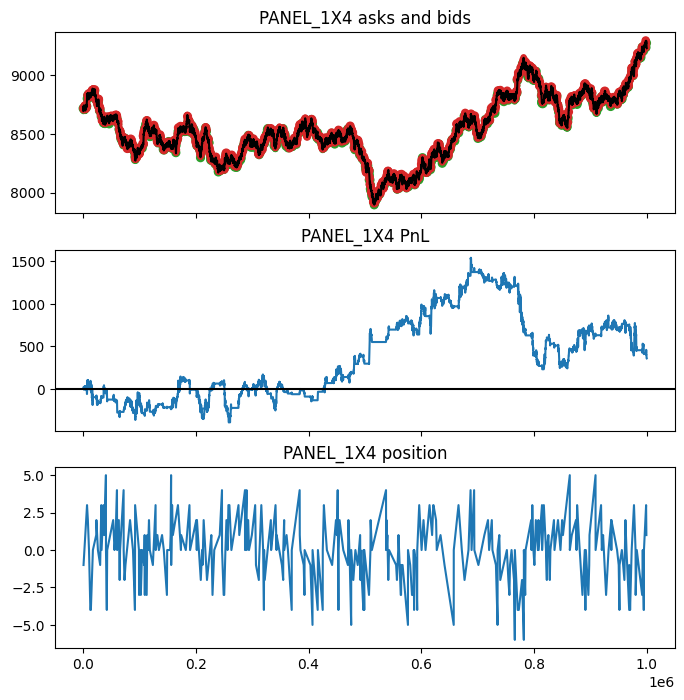

######################################################################################################################################################
PANEL_2X4 PnL: 636.5


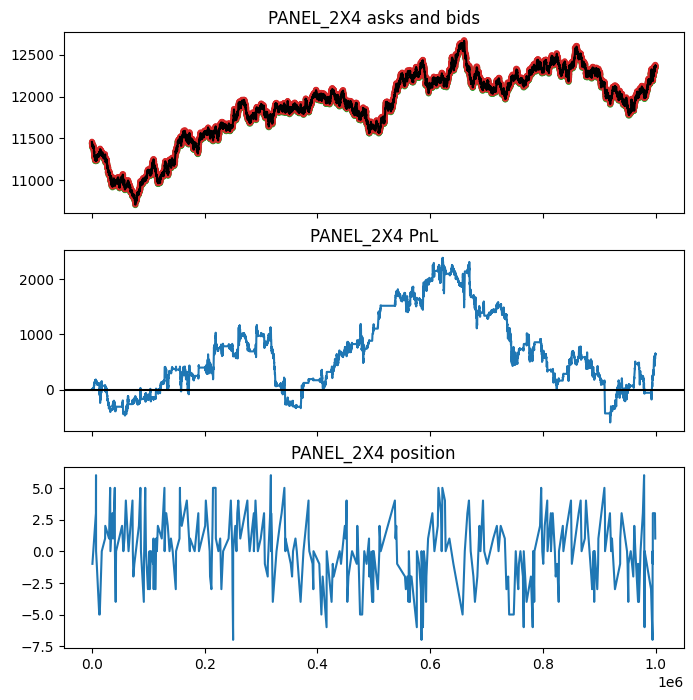

######################################################################################################################################################
PANEL_4X4 PnL: 2163.5


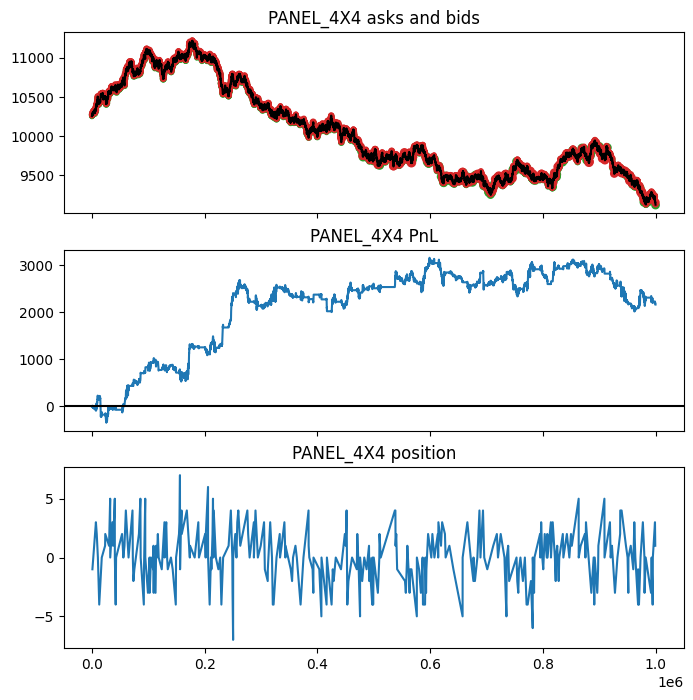

######################################################################################################################################################


In [15]:
for prod in products:
    price_prod = activities[activities['product'] == prod].reset_index(drop=True).set_index('timestamp')
    trades_prod = trades[trades['symbol'] == prod].reset_index(drop=True).set_index('timestamp')
    
    trades_prod = trades_prod.assign(
        traded=lambda x: np.where(
            x['buyer'] == 'SUBMISSION',
            x['quantity'],
            np.where(
                x['seller'] == 'SUBMISSION',
                -x['quantity'],
                0
            )
        )
    )
    trades_prod = trades_prod.assign(position=lambda x: np.cumsum(x['traded']))
    
    print(f"{prod} PnL: {price_prod['profit_and_loss'].iloc[-1]}")
    total_pnl += price_prod['profit_and_loss'].iloc[-1]
    
    ema_mean = 10000
    ema_std = 250
    price_prod = get_thrs(price_prod, ema_mean, ema_std)
    
    fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    ax[0].scatter(price_prod.index, price_prod['bid_price_1'], s=price_prod['bid_volume_1'], c='tab:green')
    ax[0].scatter(price_prod.index, price_prod['ask_price_1'], s=price_prod['ask_volume_1'], c='tab:red')
    ax[0].plot(price_prod['mid_price'], label='Filtered Mid Price', c='k')
    # ax[0].plot(price_prod['estimated_mean'], label='EMA Mean', color='k', linestyle='dashed')
    # ax[0].plot(price_prod['estimated_mean'] + 1.5 * price_prod['estimated_std'], color='k', linestyle='dotted', label='+1.5 Std')
    # ax[0].plot(price_prod['estimated_mean'] - 1.5 * price_prod['estimated_std'], color='k', linestyle='dotted', label='-1.5 Std')
    ax[0].set_title(f'{prod} asks and bids')
    ax[1].plot(price_prod['profit_and_loss'])
    ax[1].axhline(0, c='k')
    ax[1].set_title(f'{prod} PnL')
    ax[2].plot(trades_prod['position'])
    ax[2].set_title(f'{prod} position')
    plt.show()

    print("#" * 150)

In [16]:
total_pnl

np.float64(16355.5)